## Imports

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
#Importing all packages
import matplotlib.pyplot as plt
import pandas as pd
import os
# all of the core functions are in the online_gc_utils.py file. if you place your notebook somewhere else, paste this file in the same directory
import FTS_Analysis_GC as fts
from typing import Literal
import numpy as np


## Select your experiment and fill in all your details of your experiment

In [ ]:
#Establish where the data is, and selecting the experiment
root = r"raw_Data" # if your data is somewhere else, change this path
experiment_name = 'example_data/' # change this to the name of your experiment
experiment_path = os.path.join(root, experiment_name)
setup = 'FTGC' # select the setup, either 'FTGC' or  'HTHPGC' or 'LPGC'

#Reactant concentration in the gas mixture before the reactor (between 0 and 1)
ReactantConc = {
    'CO': 0.25, # molar fraction of CO
    'CO2': 0.0, # molar fraction of CO2
    'H2': 0.5, # molar fraction of H2
    'Ar': 0.1, # molar fraction of Ar
    'N2': 0.15, # molar fraction of N2
}

#Calculate conversion based on reactant 'CO'
Reactant = 'CO' # select the reactant for conversion calculation
#Calculate conversion based on product 'C1'
product = ['C1', 'C2', 'C3', 'C4'] # select the reactant for conversion calculation

#Concentration of internal standard in the gas mixture bbefore the reactor
IntStand = 'Ar' # internal standard
ISConc =  0.1 # molar fraction of internal standard 

#Intergration parameters for the FID and TCD detectors
# peak_list = [['Compound', [start, end], two_point_baselineYes/NO]]
FID_peaks = [
    ['C1', [1.84, 1.898], False],
    ['C2', [1.898, 2.0], False],
    ['C3', [2.0, 2.26], True],
    ['C4', [2.32, 2.73], True],
]
TCDLeft_peaks = [
    ['CO2', [3.53, 3.95], True],
    ['CO', [7.6, 9.2], True],
    ['Ar', [5.45, 5.86], True],
]



## Collect and import chromatograms files

### Collect chromatograms:
The collect_chromatogram_files function searches the given experiment directory for chromatogram files (FID, TCD_AuxLeft, TCD_AuxRight), categorizes them into lists, and loads the first file from each type into a DataFrame. This will tell you the number of injections

In [ ]:
#Collecting the chromatogram files
FIDList, AuxLeftList, AuxRightList = fts.collect_chromatogram_filesAll(experiment_path, setup)
print('number of injections = ' + str(len(FIDList)))
AuxLeftList



number of injections = 358


### Combine chromatograms:
The chromatogram function processes a list of chromatogram files (e.g., FID, AuxLeft, AuxRight), aligns them based on time relative to the earliest FID file, and returns a combined DataFrame saved as a CSV file. This can take a while depending on the amount of injections and computer power. Aprox 60 seconds
You only have to do this once to load your data

[INFO] Data is already loaded: FID_total.csv exists in C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250707-Co20TiO2-20Bar-10CO_20H2_6N2_4Ar-410Red-180-250FTS/.
[INFO] Data is already loaded: TCD_AuxLeft_total.csv exists in C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250707-Co20TiO2-20Bar-10CO_20H2_6N2_4Ar-410Red-180-250FTS/.
[INFO] Data is already loaded: TCD_AuxRight_total.csv exists in C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250707-Co20TiO2-20Bar-10CO_20H2_6N2_4Ar-410Red-180-250FTS/.
Date/time of the GC start: 2025-07-07 15:39:00
Peak Name   | Integration Limits   | Two Point Baseline
------------------------------------------------------
C1         | [1.84, 1.9]          | No
C2         | [1.9, 2.0]           | No
C3         | [2.0, 2.26]          | Yes
C4         | [2.32, 2.73]         | Yes
C

c:\users\6855245\onedrive - universiteit utrecht\phd\results\fts catalytic tests\fts_gc_analysisrc\FTS_Analysis_GC\FTS_Analysis_GC.py:453: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


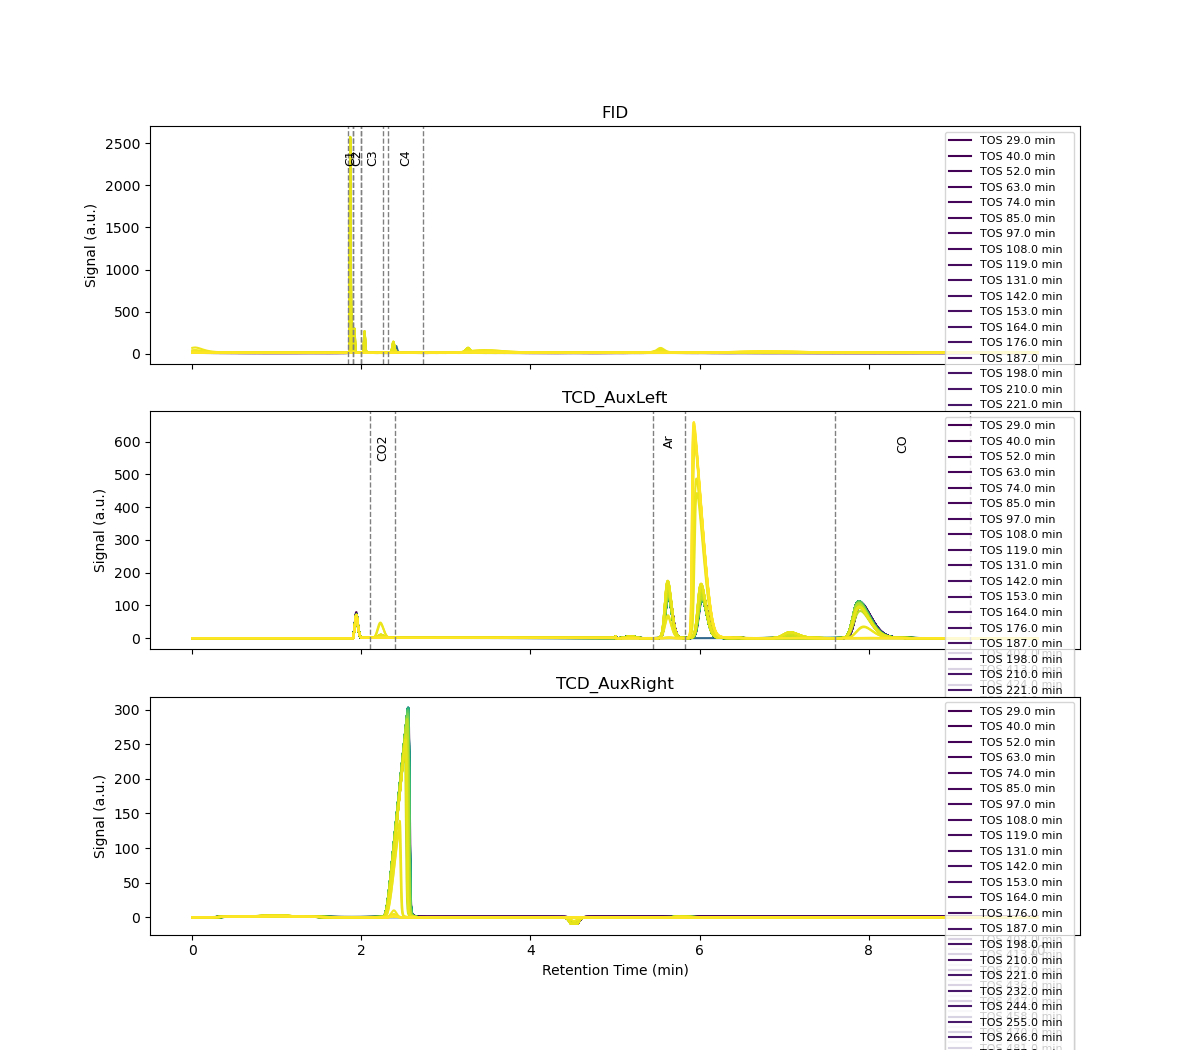

In [ ]:
# Process FID
FIDDF1, datetime_start = fts.chromatogramAll(file_list=FIDList, setup=setup, output_path=experiment_path, output_name='FID_total.csv')
# Process TCD_AuxLeft detectors
AuxLeftDF1, datetime_start = fts.chromatogramAll(file_list=AuxLeftList, setup=setup, output_path=experiment_path, output_name='TCD_AuxLeft_total.csv')
# Process TCD_AuxRight detectors
AuxRightDF1, datetime_start = fts.chromatogramAll(file_list=AuxRightList, setup=setup, output_path=experiment_path, output_name='TCD_AuxRight_total.csv')

print("Date/time of the GC start: " + str(datetime_start))

print("Date/time of the GC start: " + str(datetime_start))

#Plotting the chromatograms: Plots chromatograms from multiple channels over a specified TOS (Time on Stream) range with color mapping.
# and peak annotations.

#Intergration parameters for the FID and TCD detectors
# peak_list = [['Compound', [start, end], two_point_baselineYes/NO]]
FID_peaks = [
    ['C1', [1.84, 1.898], False],
    ['C2', [1.898, 2.0], False],
    ['C3', [2.0, 2.26], True],
    ['C4', [2.32, 2.73], True],
]
TCDLeft_peaks = [
    ['CO2', [3.53, 3.95], True],
    ['CO', [7.6, 9.2], True],
    ['Ar', [5.45, 5.86], True],
]
peak_names = [peak[0] for peak in FID_peaks + TCDLeft_peaks]
peak_dict = { 'FID': FID_peaks, 'TCD_AuxLeft': TCDLeft_peaks}
print("Peak Name   | Integration Limits   | Two Point Baseline")
print("------------------------------------------------------")
for peak in FID_peaks + TCDLeft_peaks:
    name = peak[0]
    limits = peak[1]
    baseline = "Yes" if peak[2] else "No"
    print(f"{name:<10} | {str(limits):<20} | {baseline}")

fts.plot_chromatogram(
    df_list=[FIDDF1, AuxLeftDF1, AuxRightDF1],
    labels=['FID', 'TCD_AuxLeft', 'TCD_AuxRight'],
    tos_range=(20, 3500),
    show_legend=True,
    show_peaks=True,
    peak_dict=peak_dict,
    colormap='viridis'
)

### Baseline corrections: 
The following code is used to correct the baseline of the chromatograms. 

In [17]:
FIDDF_corr = FIDDF1.apply(lambda col: fts.baseline_correct_column(col, FIDDF1.index, 0.6, 0.9))
FIDDF_corr.head(5)

,0.0,18.0,29.0,40.0,52.0,63.0,74.0,85.0,97.0,108.0,...,3939.0,3950.0,3961.0,3973.0,3984.0,3995.0,4006.0,4018.0,4029.0,4040.0
Time,,,,,,,,,,,,,,,,,,,,,
0.000000,-0.000040,0.098979,0.218836,0.197367,0.267845,0.329377,0.421270,0.560074,0.752813,0.819433,...,0.746940,0.643857,0.542960,0.694496,0.828151,0.596348,0.552773,0.526555,0.466469,0.464843
0.000667,-0.008691,0.135719,0.198939,0.214493,0.299057,0.334991,0.424079,0.543488,0.742896,0.821792,...,0.766445,0.653758,0.569663,0.707759,0.843640,0.652825,0.560550,0.521391,0.472848,0.450203
0.001333,0.019446,0.165973,0.197837,0.201777,0.282884,0.311473,0.460318,0.553206,0.713215,0.837656,...,0.771840,0.661676,0.552066,0.720352,0.813347,0.624552,0.533362,0.516893,0.462640,0.448300
0.002000,0.009699,0.135168,0.223813,0.215604,0.286219,0.308126,0.450685,0.574385,0.763318,0.823550,...,0.766445,0.635966,0.580742,0.697817,0.826811,0.655462,0.535952,0.551082,0.471569,0.448936
0.002667,-0.003285,0.141214,0.200600,0.220033,0.273410,0.347879,0.450685,0.586437,0.768574,0.805962,...,0.757033,0.630033,0.545557,0.714382,0.807292,0.659410,0.548891,0.510436,0.471569,0.460379


## Intergration and data analysis

### Intergration:
 Do intergrations based on the intergration limits set in FID_peaks, TCDLeft_peaks and TCDRight_peaks. Parse logfile with the intergration values of the reactants and products based on the timestamp of the injection into the GC. and plotting the raw areas against time on steam

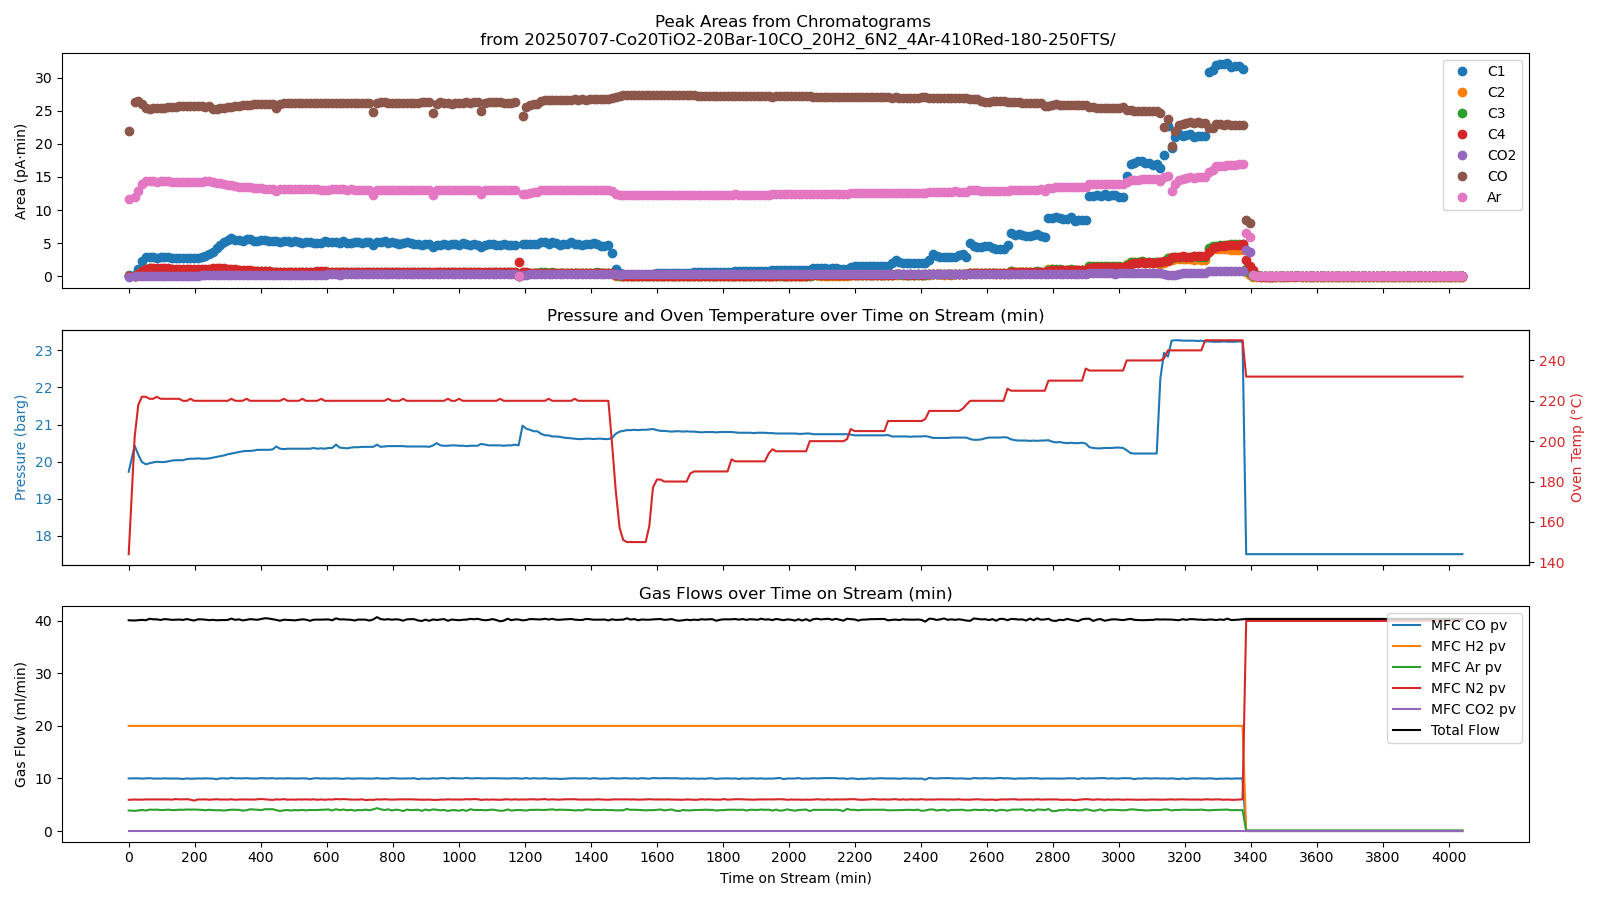

In [ ]:
area_FIDDF = fts.integrate_named_peaks(FIDDF_corr, FID_peaks)
area_AuxLeft = fts.integrate_named_peaks(AuxLeftDF1, TCDLeft_peaks)
area_totalDF = pd.concat([area_FIDDF, area_AuxLeft], axis=1)
area_totalDF.index.name = "TOS"

area_totalFig = plt.figure()
area_totalFigAx = area_totalFig.add_subplot()
for name in area_totalDF.columns:
    area_totalFigAx.plot(area_totalDF[name], label=name, linestyle='',
                                                  marker='o')
area_totalFigAx.legend()
area_totalFigAx.set_xlabel('Time on Stream (min)')
area_totalFigAx.set_ylabel('Area (pA*min)')
area_totalFigAx.title.set_text('Area of all integrations of sample: ' + experiment_path)
#area_totalFigAx.set_ylim(0,2.5)
area_totalDF.to_excel(experiment_path + '/Raw_Areas.xlsx')


### Area to concentration factor
Converting the area into concentration factor by using the correction factor. This correciton is done by dividing the area of the peak by the correction factor of that corresponding peak. The value is a factor of the total gas flow including reactants, products and inert

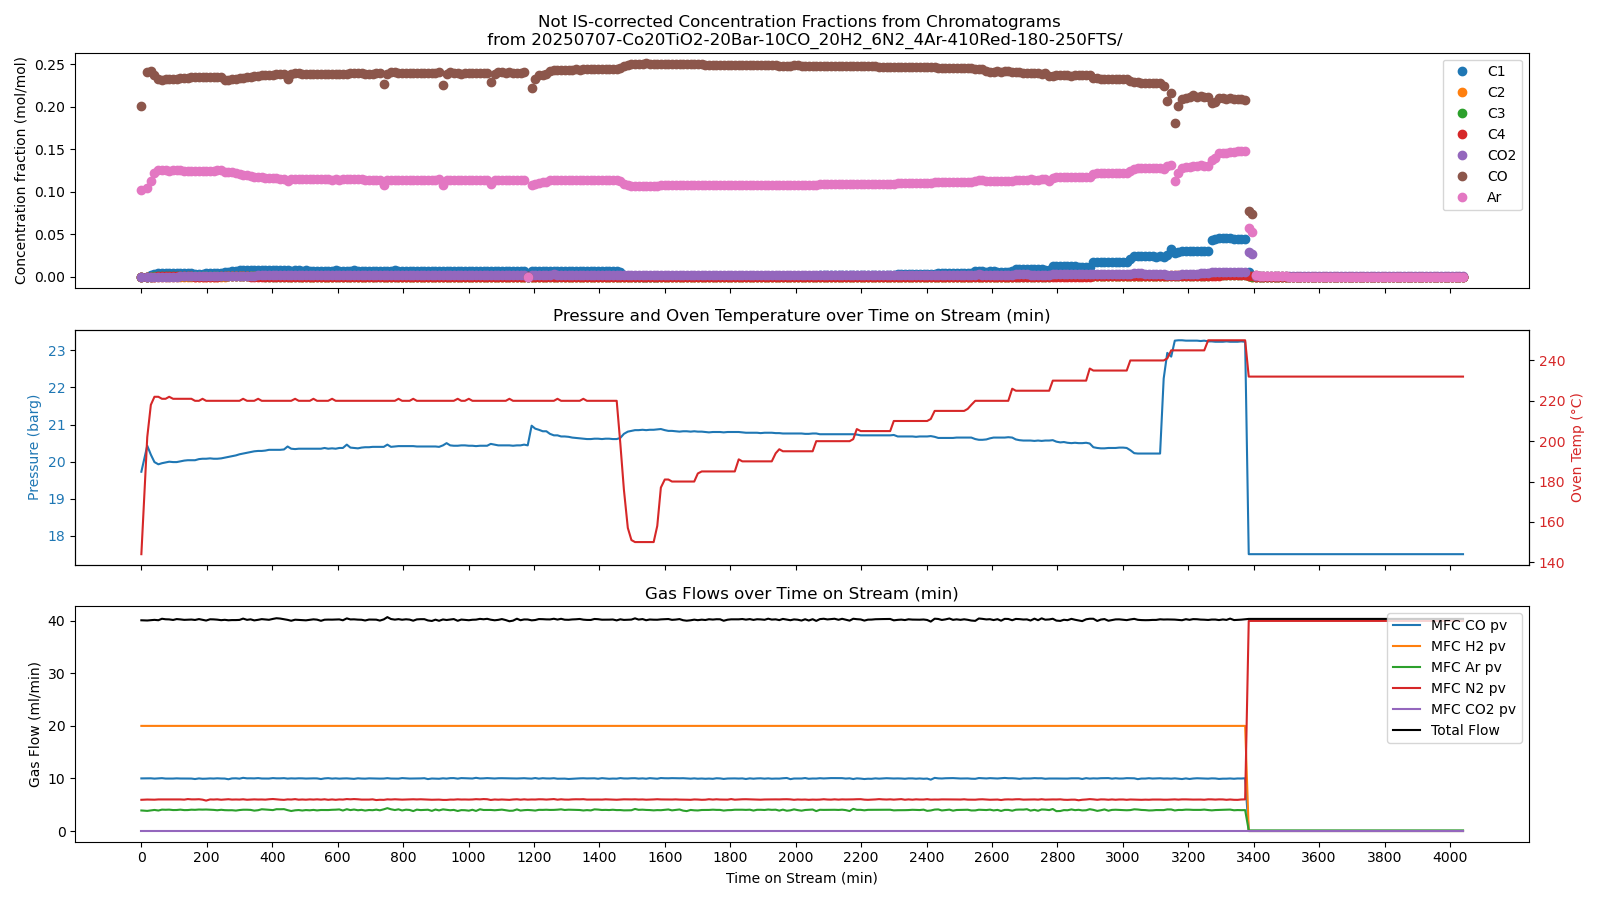

In [ ]:
#Correction factors for the FTS setup for 40 ml/min of total gas flow
# Date: 01 april 2025
C1 = 705.88
FTCorrectionFactorsDict = {
'C1' : C1,
'C2' : C1 * 2,
'C3' : C1 * 3,
'C4' : C1 * 4,
'CO2': 134.56,
'CO' : 109.34,
'Ar' : 114.48,
'N2' : 112.57,
'H2' : 91
}

AmountsDF = pd.DataFrame(index=area_totalDF.index)
AmountsDF = area_totalDF.copy()
NoIntegrationValues = []
for name in peak_names:
    if name in area_totalDF.columns:
        if name in FTCorrectionFactorsDict:
            AmountsDF[name] = area_totalDF[name] / FTCorrectionFactorsDict[name]
        else:
            NoIntegrationValues.append(name)
    else:
        print(f"Warning: Peak '{name}' not found in area_totalDF.")
AmountsDF.to_excel(experiment_path + '/Amounts_corrected_peaks.xlsx')

# --- Optional: Report missing correction factors ---
if NoIntegrationValues:
    print("No correction factor found for:", NoIntegrationValues)
    
# Plot the calculated amounts for each peak as a function of time
AmountsFig = plt.figure()
AmountsFigAx = AmountsFig.add_subplot()
for name in AmountsDF.columns:
    AmountsFigAx.plot(AmountsDF[name], label=name, linestyle='', marker='o')
AmountsFigAx.legend()
AmountsFigAx.set_xlabel('Time on Steam (minutes)')
AmountsFigAx.set_ylabel('Amount')
AmountsFigAx.title.set_text('Amounts of all integrations of sample: ' + experiment_path)

### Internal standaard correction:
The GasContractionFactor is calculated for each injection by dividing the internal standaard concentration in the GC by the internal standaard concentration before the reactor (from your MFC's). 
C5+ selectivity can be calculated by substracting the unconverted CO and all the C1-C4 and CO2 product from the incoming CO. 
Only valid when assuming complete carbon balance (no coke formation)

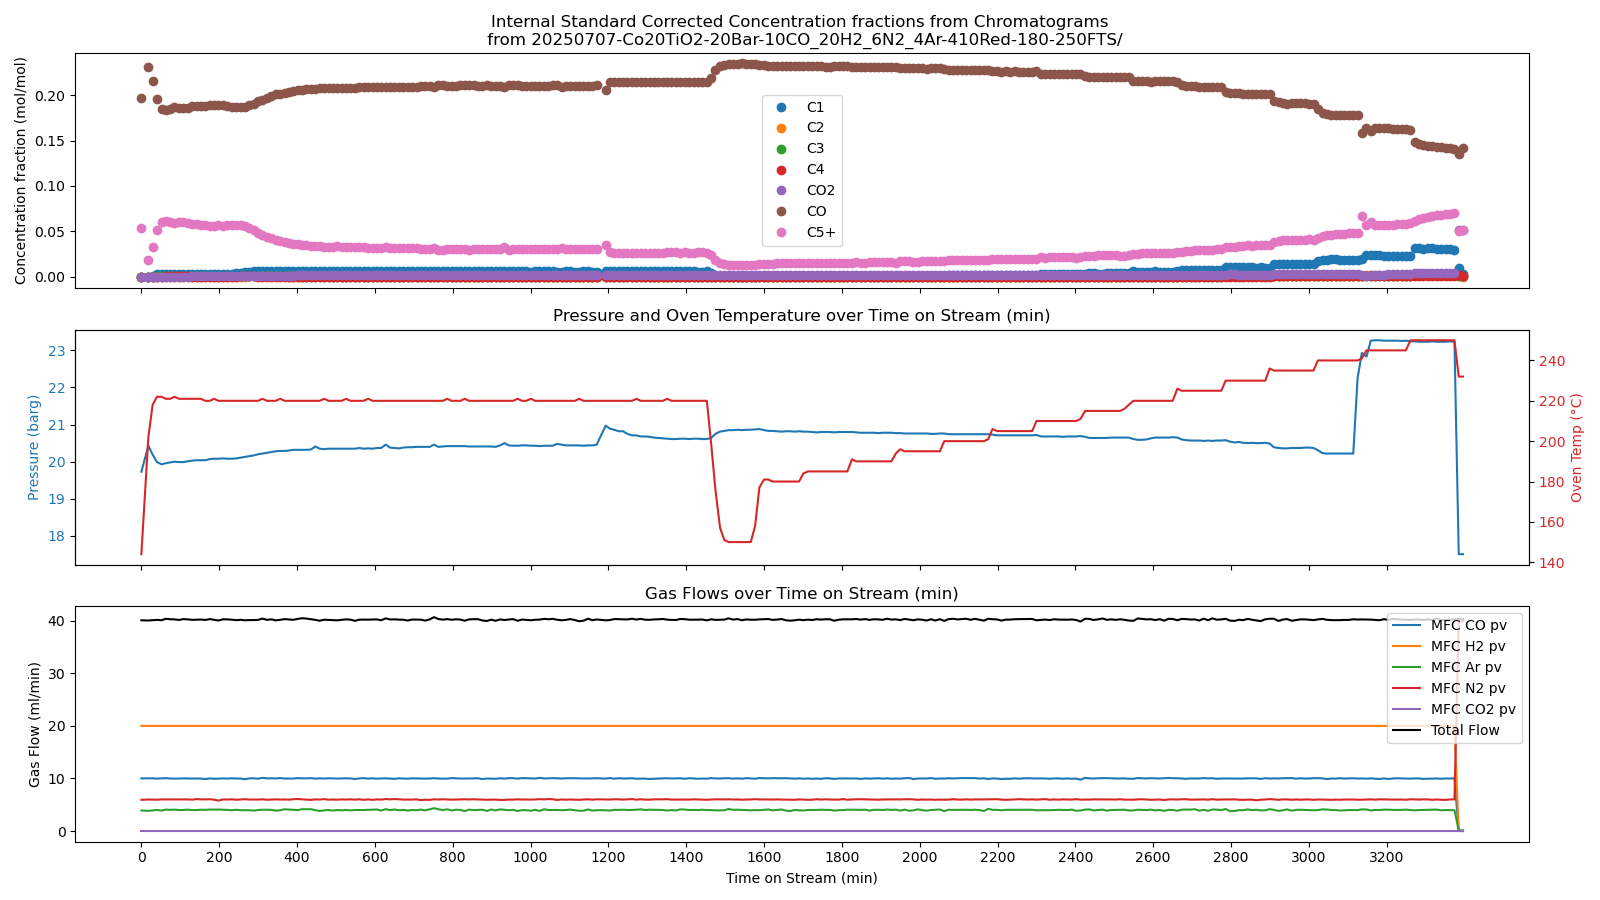

In [ ]:
is_logDF = AmountsDF.copy()
is_logDF['GasContractionFactor'] = is_logDF[IntStand] / ISConc # Compute Gas Contraction Factor
is_logDF = is_logDF[is_logDF['GasContractionFactor'] > 0.1] #Filter out rows with very low internal standard signal
for col in peak_names: #Apply internal standard correction only to peak_names
    if col in is_logDF.columns:
        is_logDF[col] = is_logDF[col] / is_logDF['GasContractionFactor']
is_logDF = is_logDF.drop(columns=['GasContractionFactor', IntStand])
is_logDF['C5+'] = ReactantConc['CO'] - is_logDF['C1'] - is_logDF['C2'] - is_logDF['C3'] - is_logDF['C4'] - is_logDF['CO2'] - is_logDF['CO']
is_logDF.to_excel(experiment_path + '/Amounts_iscorr+factor_between_0and1.xlsx')
IntStandAmountsFig = plt.figure()
IntStandAmountsFigAx = IntStandAmountsFig.add_subplot()
for name in is_logDF.columns:
    IntStandAmountsFigAx.plot(is_logDF[name], label=name, linestyle='',marker='o')
IntStandAmountsFigAx.legend()
IntStandAmountsFigAx.set_xlabel('Time (minutes)')
IntStandAmountsFigAx.set_ylabel('Amount')
#IntStandAmountsFigAx.set_xlim(0, 1400)
#IntStandAmountsFigAx.set_ylim(0, 0.03)
IntStandAmountsFigAx.title.set_text('Amounts of all integrations - Internal standard corrected \n -  of sample: ' + experiment_name)

### Conversion calculation

Calculate reactant and/or product conversion. This is based on the following formula conversion = ((set_concentration-reactant_amount)/set_concentration)*100. The values are taken from the internal standard corrected concentation fraction. Adjust the figure accordingly to better see your conversion

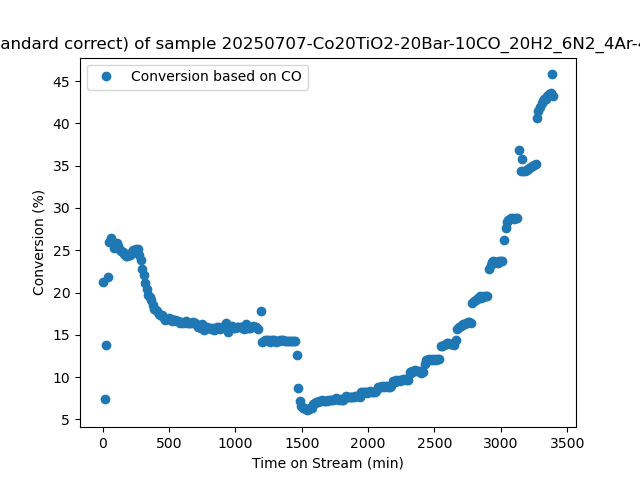

In [26]:
Reactant = 'CO'

# Calculate conversion based on reactant
def calculate_conversion_based_on_reactant(isDF,reactant,reactant_initial_concentration):
    reactant_amount = isDF[reactant]
    conversion = ((reactant_initial_concentration-reactant_amount)/reactant_initial_concentration)*100
    return conversion

ReactantConversion = calculate_conversion_based_on_reactant(is_logDF,Reactant, ReactantConc[Reactant])
#ProductConversion = calculate_conversion_based_on_reactant(isDF,product, FTCorrectionFactorsDict['C1'])
ConversionPlot = plt.figure()
ConversionPlotAx = ConversionPlot.add_subplot()
ConversionPlotAx.plot(ReactantConversion, label='Conversion based on ' + Reactant,
                        linestyle='', marker='o')
#ConversionPlotAx.plot(ProductConversion, label='Conversion based on ' + product,
                       # linestyle='', marker='o')
ConversionPlotAx.legend()
ConversionPlotAx.set_xlabel('Time on Stream (min)')
ConversionPlotAx.set_ylabel('Conversion (%)')
#ConversionPlotAx.set_ylim(0, 30)  # Set y-axis from 0 to 20
#ConversionPlotAx.set_xlim(0, 3000)
ConversionPlotAx.title.set_text('Conversions (int standard correct) of sample ' + experiment_name)
#ConversionPlot.show()
ConversionsDF = pd.concat([ReactantConversion], axis=1)
ConversionsDF.to_excel(experiment_path + '/conversions.xlsx')

Calculate conversion based on products and combining them into one file

C:\Users\6855245\AppData\Local\Temp\ipykernel_2368\746907859.py:14: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  interpolated_df = df[products].interpolate(method='pad')


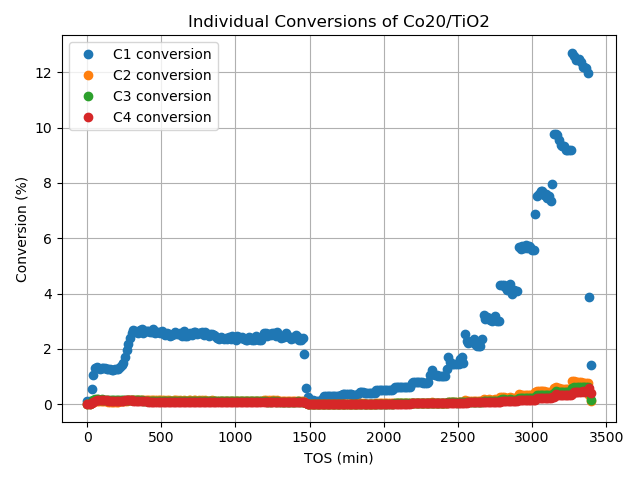

In [15]:
def calculate_individual_conversions(df, products, reactant_initial_concentration):
    """
    Calculates conversion (%) separately for each product over TOS.

    Parameters:
        df (pd.DataFrame): DataFrame with product amounts (columns) over time (index = TOS).
        products (list of str): List of product column names to calculate conversion from.
        reactant_initial_concentration (float): Initial concentration of the reactant.

    Returns:
        pd.DataFrame: Conversion (%) for each product over time.
    """
    # Interpolate missing data if any (forward fill)
    interpolated_df = df[products].interpolate(method='pad')

    # Initialize a DataFrame to store conversions
    conversion_df = pd.DataFrame(index=interpolated_df.index)

    # Calculate conversion for each product separately
    for product in products:
        converted = interpolated_df[product]
        conversion = (1 - ((reactant_initial_concentration - converted) / reactant_initial_concentration)) * 100
        conversion_df[product + ' conversion'] = conversion

    return conversion_df
    
products = ['C1', 'C2', 'C3', 'C4']

conversion_df = calculate_individual_conversions(
    df=is_logDF, 
    products=products, 
    reactant_initial_concentration=ReactantConc[Reactant]
)
conversion_df.to_excel(experiment_path + '/individual_conversions.xlsx')
conversion_df.plot(linestyle='', marker='o')
plt.title("Individual Conversions of Co20/TiO2")
plt.xlabel("TOS (min)")
plt.ylabel("Conversion (%)")
plt.grid(True)
#plt.xlim(0,1500)
#plt.ylim(0,1.5)
plt.tight_layout()
plt.show()
